Data Cleaning

In [2]:
import pandas as pd
df=pd.read_csv(r"C:\Users\siddh\OneDrive\Desktop\sc_git_demo\movies.csv")
# Step 1: Convert to string
clean = df["released"].astype(str)

# Step 2: Remove country part
clean = clean.str.replace(r"\s*\(.*\)", "", regex=True)

# Step 3: Add day = 1 where missing (no comma → no day)
mask = ~clean.str.contains(",") & (clean != "nan")
clean.loc[mask] = clean.loc[mask] + " 1"

# Step 4: Convert to datetime
df["clean_date"] = pd.to_datetime(clean, format="mixed", errors="coerce")

# Step 5: Extract
df["release_month"] = df["clean_date"].dt.month
df["release_day"] = df["clean_date"].dt.day
df=df[df["country"]=="United States"]
df["roi"] = df["gross"] / df["budget"]
bins = [0, 0.5, 1, 2, float("inf")]
labels = ["flop", "below_avg", "hit", "blockbuster"]
df=df.drop("clean_date", axis=1)
df["roi_class"] = pd.cut(df["roi"], bins=bins, labels=labels)
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,release_month,release_day,roi,roi_class
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0,7.0,2.0,13.078468,blockbuster
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0,6.0,20.0,29.909726,blockbuster
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0,7.0,2.0,23.843868,blockbuster
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0,7.0,25.0,6.641057,blockbuster
5,Friday the 13th,R,Horror,1980,"May 9, 1980 (United States)",6.4,123000.0,Sean S. Cunningham,Victor Miller,Betsy Palmer,United States,550000.0,39754601.0,Paramount Pictures,95.0,5.0,9.0,72.281093,blockbuster


In [3]:
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(1)
 
summary = pd.DataFrame({
    "missing_rows": missing,
    "percentage":   pct
}).sort_values("missing_rows", ascending=False)
 
print(summary.to_string())

               missing_rows  percentage
roi_class              1149        21.0
roi                    1149        21.0
budget                 1099        20.1
gross                    98         1.8
rating                   18         0.3
company                  12         0.2
votes                     3         0.1
score                     3         0.1
runtime                   2         0.0
genre                     0         0.0
name                      0         0.0
country                   0         0.0
star                      0         0.0
writer                    0         0.0
director                  0         0.0
year                      0         0.0
released                  0         0.0
release_day               0         0.0
release_month             0         0.0


In [ ]:
# df.to_excel("movies_cleaned.xlsx")

ROI VS BUDGET CORRELATION

In [4]:
df[["budget", "roi"]].corr().round(2)

,budget,roi
budget,1.00,-0.02
roi,-0.02,1.00


In [5]:
# Order
order = ["Low", "Mid", "High", "Very High"]

# --- IQR Capping ---
Q1 = df["roi"].quantile(0.25)
Q3 = df["roi"].quantile(0.75)
IQR = Q3 - Q1

lower_cap = Q1 - 1.5 * IQR
upper_cap = Q3 + 1.5 * IQR
df["budget_bucket"] = pd.qcut(df["budget"], q=4, labels=["low", "mid", "high", "very_high"])
df["roi_capped"] = df["roi"].clip(lower=lower_cap, upper=upper_cap)
df["budget_bucket"] = pd.qcut(df["budget"], q=4, labels=["low", "mid", "high", "very_high"])
df["roi_capped"] = df["roi"].clip(lower=lower_cap, upper=upper_cap)

df["budget_bucket"] = pd.qcut(df["budget"], q=4, labels=["low", "mid", "high", "very_high"])
df.groupby("budget_bucket")["roi_capped"].quantile([0.25, 0.5, 0.75]).unstack()

C:\Users\siddh\AppData\Local\Temp\ipykernel_20808\3168917902.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("budget_bucket")["roi_capped"].quantile([0.25, 0.5, 0.75]).unstack()


,0.25,0.50,0.75
budget_bucket,,,
low,0.614643,2.058782,5.404698
mid,0.616264,1.664536,3.499576
high,0.726999,1.680543,3.303858
very_high,1.325279,2.296787,3.670503


C:\Users\siddh\AppData\Local\Temp\ipykernel_20808\1570715172.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\siddh\AppData\Local\Temp\ipykernel_20808\1570715172.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quartiles = df.groupby("budget_bucket")["roi_capped"].quantile([0.25, 0.5, 0.75]).unstack().reindex(order)


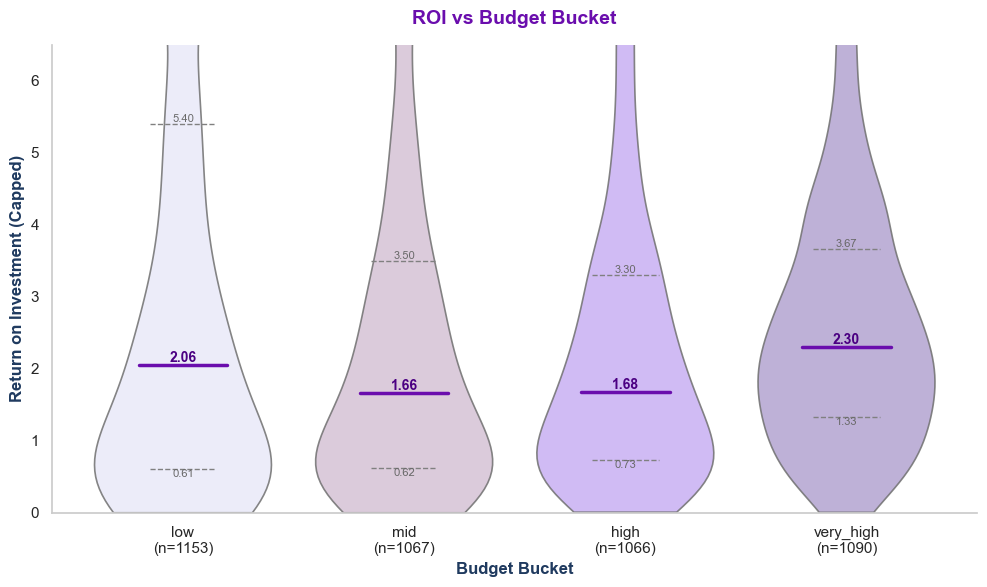

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Style (clean + modern) ---
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12
})

# Order
order = ["low", "mid", "high", "very_high"]

# --- IQR Capping ---
Q1 = df["roi"].quantile(0.25)
Q3 = df["roi"].quantile(0.75)
IQR = Q3 - Q1

lower_cap = Q1 - 1.5 * IQR
upper_cap = Q3 + 1.5 * IQR
df["budget_bucket"] = pd.qcut(df["budget"], q=4, labels=["low", "mid", "high", "very_high"])

df["roi_capped"] = df["roi"].clip(lower=lower_cap, upper=upper_cap)

# --- Counts ---
counts = df["budget_bucket"].value_counts().reindex(order)
labels_with_counts = [f"{b}\n(n={counts[b]})" for b in order]

# --- Pastel palette (Accenture-inspired purples/blues) ---
palette = ["#E6E6FA", "#D8BFD8", "#C5A3FF", "#B19CD9"]  # soft lavender shades

# --- Plot ---
plt.figure(figsize=(10,6))

sns.violinplot(
    x="budget_bucket",
    y="roi_capped",
    data=df,
    order=order,
    inner=None,
    cut=0,
    palette=palette,
    linewidth=1.2
)

# Slight transparency for depth
for violin in plt.gca().collections:
    violin.set_alpha(0.85)

# --- TRUE Quartiles ---
quartiles = df.groupby("budget_bucket")["roi_capped"].quantile([0.25, 0.5, 0.75]).unstack().reindex(order)

for i, bucket in enumerate(order):
    q1, median, q3 = quartiles.loc[bucket]

    # Median (Accenture purple)
    plt.plot([i-0.2, i+0.2], [median, median], color='#6A0DAD', linewidth=2.5)

    # Q1 & Q3 (soft grey)
    plt.plot([i-0.15, i+0.15], [q1, q1], color='gray', linestyle='--', linewidth=1)
    plt.plot([i-0.15, i+0.15], [q3, q3], color='gray', linestyle='--', linewidth=1)

    # Labels
    plt.text(i, median, f"{median:.2f}", ha='center', va='bottom', color='#4B0082', fontsize=10, weight='bold')
    plt.text(i, q1, f"{q1:.2f}", ha='center', va='top', fontsize=8, color='dimgray')
    plt.text(i, q3, f"{q3:.2f}", ha='center', va='bottom', fontsize=8, color='dimgray')

# --- Axis styling ---
plt.xticks(ticks=range(len(order)), labels=labels_with_counts)
plt.ylim(0, 6.5)
plt.yticks([0,1,2,3,4,5,6])

# --- Axis label styling (Accenture-inspired) ---
accent_purple = "#6A0DAD"   # Accenture purple
dark_blue = "#1F3A5F"       # deep consulting blue
plt.title("ROI vs Budget Bucket", color=accent_purple,weight='bold', pad=15)
plt.xlabel("Budget Bucket", color=dark_blue, weight='bold')
plt.ylabel("Return on Investment (Capped)", color=dark_blue, weight='bold')
# Clean spines
sns.despine(left=False, bottom=False)
plt.grid(False)
plt.tight_layout()
plt.show()

Genre EDA

In [7]:
df.groupby("genre").agg(
    movie_count=("name", "count"),
    median_roi=("roi", "median")
).sort_values(by="movie_count", ascending=False)

,movie_count,median_roi
genre,,
Comedy,1803,1.867359
Action,1298,1.893062
Drama,902,1.815522
Crime,380,1.408240
Adventure,277,2.090370
Biography,252,1.560683
Horror,246,3.220880
Animation,237,3.229358
Fantasy,34,2.617178


EDA Dashboard

In [11]:
import pandas as pd
import plotly.express as px
from dash import Dash, dcc, html, Input, Output

# =========================================
# THEME
# =========================================
ACCENTURE_PURPLE = "#A100FF"
LIGHT_BG = "#F7F7F7"
FONT_FAMILY = "Arial"

# =========================================
# LOAD DATA
# =========================================
df_main = df.copy()
all_years = sorted(df_main["year"].dropna().unique())

# =========================================
# -------- GENRE DASHBOARD ---------------
# =========================================
df1 = df_main.dropna(subset=["year", "genre", "roi", "budget"]).copy()
top_genres = df1["genre"].value_counts().head(8).index
df1 = df1[df1["genre"].isin(top_genres)]

df1_grouped = (
    df1.groupby(["year", "genre"])
    .agg(roi=("roi", "median"),
         movies=("genre", "count"),
         budget=("budget", "median"))
    .reset_index()
).sort_values(["genre", "year"])

df1_grouped["roi_smooth"] = df1_grouped.groupby("genre")["roi"].transform(lambda x: x.rolling(3,1).mean())
df1_grouped["movies_smooth"] = df1_grouped.groupby("genre")["movies"].transform(lambda x: x.rolling(3,1).mean())
df1_grouped["budget_smooth"] = df1_grouped.groupby("genre")["budget"].transform(lambda x: x.rolling(3,1).mean())

def style_fig(fig):
    fig.update_layout(
        plot_bgcolor=LIGHT_BG,
        paper_bgcolor=LIGHT_BG,
        font=dict(family=FONT_FAMILY),
        xaxis=dict(showgrid=False),
        yaxis=dict(showgrid=False)
    )
    return fig

def fig_genre(metric, year_range, highlight=None):
    data = df1_grouped[
        (df1_grouped["year"] >= year_range[0]) &
        (df1_grouped["year"] <= year_range[1])
    ]

    if data.empty:
        return px.scatter(title="No data available")

    y_map = {"roi": "roi_smooth", "movies": "movies_smooth", "budget": "budget_smooth"}

    fig = px.line(
        data,
        x="year",
        y=y_map[metric],
        color="genre",
        markers=True,
        color_discrete_sequence=px.colors.qualitative.Set2
    )

    for t in fig.data:
        if highlight is None:
            t.opacity = 0.7
        else:
            if t.name == highlight:
                t.opacity = 1
                t.line.width = 5
                t.line.color = ACCENTURE_PURPLE
            else:
                t.opacity = 0.15

    # 🔥 ROI LIMIT (visual only)
    if metric == "roi":
        fig.update_yaxes(range=[0, 15])

    return style_fig(fig)


# =========================================
# -------- ACTOR/DIRECTOR DASH -----------
# =========================================
df2 = df_main.dropna(subset=["year", "star", "director", "gross", "roi"]).copy()
df2["year_bin"] = (df2["year"] // 5) * 5
df2["year_label"] = df2["year_bin"].astype(str) + "-" + (df2["year_bin"] + 4).astype(str)

def get_top_entities(data, entity, metric, top_n):
    col = "star" if entity == "actor" else "director"

    agg = data.groupby(col).agg(
        movies=("year", "count"),
        gross=("gross", "sum"),
        roi=("roi", "median")
    ).reset_index()

    sort_col = "gross" if metric == "roi" else metric
    return agg.sort_values(sort_col, ascending=False).head(top_n)[col].tolist()

def fig_actor(entity, metric, top_n, year_range, highlight=None):
    data = df2[
        (df2["year"] >= year_range[0]) &
        (df2["year"] <= year_range[1])
    ]

    if data.empty:
        return px.scatter(title="No data available")

    col = "star" if entity == "actor" else "director"
    top_entities = get_top_entities(data, entity, metric, top_n)
    data = data[data[col].isin(top_entities)]

    grouped = data.groupby(["year_label", col]).agg(
        movies=("year", "count"),
        gross=("gross", "sum"),
        roi=("roi", "median")
    ).reset_index().sort_values("year_label")

    fig = px.line(
        grouped,
        x="year_label",
        y=metric,
        color=col,
        markers=True,
        color_discrete_sequence=px.colors.qualitative.Set2
    )

    for t in fig.data:
        if highlight is None:
            t.opacity = 0.7
        else:
            if t.name == highlight:
                t.opacity = 1
                t.line.width = 5
                t.line.color = ACCENTURE_PURPLE
            else:
                t.opacity = 0.15

    return style_fig(fig)


# =========================================
# -------- COMBO DASH ---------------------
# =========================================
df3 = df_main.dropna(subset=["star", "director", "genre", "gross", "roi", "name"]).copy()

def prepare_combo(combo_type):
    temp = df3.copy()

    if combo_type == "actor_director":
        temp["combo"] = temp["star"] + " | " + temp["director"]
    elif combo_type == "actor_genre":
        temp["combo"] = temp["star"] + " | " + temp["genre"]
    else:
        temp["combo"] = temp["star"] + " | " + temp["director"] + " | " + temp["genre"]

    # 🔥 ADD MOVIE LIST
    return temp.groupby("combo").agg(
        movies=("roi", "count"),
        gross=("gross", "sum"),
        roi=("roi", "median"),
        movie_list=("name", lambda x: "<br>".join(["• " + m for m in x.head(5)]))
    ).reset_index()

combo_cache = {
    "actor_director": prepare_combo("actor_director"),
    "actor_genre": prepare_combo("actor_genre"),
    "actor_full": prepare_combo("actor_full"),
}

def fig_combo(combo_type, metric, top_n, min_movies, highlight=None):
    data = combo_cache[combo_type].copy()
    data = data[data["movies"] >= min_movies]

    if data.empty:
        return px.scatter(title="No data available")

    sort_col = "gross" if metric == "roi" else metric
    data = data.sort_values(sort_col, ascending=False).head(top_n)

    fig = px.bar(
        data,
        x=metric,
        y="combo",
        orientation="h",
        color_discrete_sequence=[ACCENTURE_PURPLE]
    )

    fig.update_yaxes(autorange="reversed")

    # 🔥 TOOLTIP WITH MOVIES
    for trace in fig.data:
        combo_name = trace.name
        movie_text = data.loc[data["combo"] == combo_name, "movie_list"].values
        movie_text = movie_text[0] if len(movie_text) > 0 else "N/A"

        trace.customdata = [[movie_text]] * len(trace.y)
        trace.hovertemplate = (
            "<b>%{y}</b><br>" +
            f"{metric}: %{{x:.2f}}<br><br>" +
            "<b>Movies:</b><br>%{customdata[0]}<extra></extra>"
        )

    for t in fig.data:
        if highlight is None:
            t.opacity = 0.85
        else:
            if t.name == highlight:
                t.opacity = 1
                t.marker.color = ACCENTURE_PURPLE
            else:
                t.opacity = 0.2

    return style_fig(fig)


# =========================================
# APP (UNCHANGED)
# =========================================
app = Dash(__name__)

app.layout = html.Div([
    html.H1("🎬 Movie Analytics Dashboard",
            style={"color": ACCENTURE_PURPLE, "fontFamily": FONT_FAMILY}),

    dcc.RangeSlider(
        id="global-year",
        min=min(all_years),
        max=max(all_years),
        value=[min(all_years), max(all_years)],
        marks={int(y): str(int(y)) for y in all_years[::5]}
    ),

    dcc.Tabs(
        id="tabs",
        value="tab1",
        colors={
            "border": ACCENTURE_PURPLE,
            "primary": ACCENTURE_PURPLE,
            "background": LIGHT_BG
        },
        children=[
            dcc.Tab(label="Genre Trends", value="tab1",
                    style={"color": ACCENTURE_PURPLE, "fontWeight": "bold"}),
            dcc.Tab(label="Actor/Director", value="tab2",
                    style={"color": ACCENTURE_PURPLE, "fontWeight": "bold"}),
            dcc.Tab(label="Combos", value="tab3",
                    style={"color": ACCENTURE_PURPLE, "fontWeight": "bold"}),
        ]
    ),

    html.Div(id="tab1", children=[
        dcc.Dropdown(id="metric1", options=[
            {"label": "ROI", "value": "roi"},
            {"label": "Movies", "value": "movies"},
            {"label": "Budget", "value": "budget"},
        ], value="roi"),
        dcc.Graph(id="graph1", clear_on_unhover=True)
    ]),

    html.Div(id="tab2", children=[
        dcc.Dropdown(id="entity2", options=[
            {"label": "Actor", "value": "actor"},
            {"label": "Director", "value": "director"},
        ], value="actor"),
        dcc.Dropdown(id="metric2", options=[
            {"label": "Movies", "value": "movies"},
            {"label": "Gross", "value": "gross"},
            {"label": "ROI", "value": "roi"},
        ], value="movies"),
        dcc.Slider(id="topn2", min=5, max=20, value=10),
        dcc.Graph(id="graph2", clear_on_unhover=True)
    ]),

    html.Div(id="tab3", children=[
        dcc.Dropdown(id="combo3", options=[
            {"label": "Actor+Director", "value": "actor_director"},
            {"label": "Actor+Genre", "value": "actor_genre"},
            {"label": "Full Combo", "value": "actor_full"},
        ], value="actor_director"),
        dcc.Dropdown(id="metric3", options=[
            {"label": "Movies", "value": "movies"},
            {"label": "Gross", "value": "gross"},
            {"label": "ROI", "value": "roi"},
        ], value="gross"),
        dcc.Slider(id="topn3", min=5, max=20, value=10),
        dcc.Slider(id="minmovies3", min=1, max=10, value=3),
        dcc.Graph(id="graph3", clear_on_unhover=True)
    ])
])

@app.callback(
    Output("tab1", "style"),
    Output("tab2", "style"),
    Output("tab3", "style"),
    Input("tabs", "value")
)
def show_tab(tab):
    hidden = {"display": "none"}
    visible = {"display": "block"}
    return (
        visible if tab == "tab1" else hidden,
        visible if tab == "tab2" else hidden,
        visible if tab == "tab3" else hidden
    )

@app.callback(Output("graph1", "figure"),
              Input("graph1", "hoverData"),
              Input("metric1", "value"),
              Input("global-year", "value"))
def update1(h, m, y):
    highlight = None
    base = fig_genre(m, y)
    if h:
        idx = h["points"][0]["curveNumber"]
        if idx < len(base.data):
            highlight = base.data[idx].name
    return fig_genre(m, y, highlight)

@app.callback(Output("graph2", "figure"),
              Input("graph2", "hoverData"),
              Input("entity2", "value"),
              Input("metric2", "value"),
              Input("topn2", "value"),
              Input("global-year", "value"))
def update2(h, e, m, t, y):
    highlight = None
    base = fig_actor(e, m, t, y)
    if h:
        idx = h["points"][0]["curveNumber"]
        if idx < len(base.data):
            highlight = base.data[idx].name
    return fig_actor(e, m, t, y, highlight)

@app.callback(Output("graph3", "figure"),
              Input("graph3", "hoverData"),
              Input("combo3", "value"),
              Input("metric3", "value"),
              Input("topn3", "value"),
              Input("minmovies3", "value"))
def update3(h, c, m, t, minm):
    highlight = None
    base = fig_combo(c, m, t, minm)
    if h:
        idx = h["points"][0]["curveNumber"]
        if idx < len(base.data):
            highlight = base.data[idx].name
    return fig_combo(c, m, t, minm, highlight)

if __name__ == "__main__":
    app.run(debug=True)